# 🌌 GSoC 2026 — DeepLense Test VII: Physics-Guided ML (PINN)

**Task:** Classify gravitational lensing images into three substructure classes using a  
**Physics-Informed Neural Network (PINN)** that embeds the gravitational lensing equation.

**Classes:**
- `Class 0 (no)` — No substructure: smooth mass distribution
- `Class 1 (sphere)` — Subhalo substructure: localised dark matter clumps
- `Class 2 (vort)` — Vortex substructure: rotating perturbation field

**Evaluation:** ROC-AUC (per-class one-vs-rest + macro-averaged)

---

## 🔭 The Physics Foundation

### The Gravitational Lensing Equation

The core equation governing strong gravitational lensing is the **lens equation**:

$$\boldsymbol{\beta} = \boldsymbol{\theta} - \boldsymbol{\alpha}(\boldsymbol{\theta})$$

where:
- $\boldsymbol{\theta}$ — observed image-plane position (what we see)
- $\boldsymbol{\beta}$ — true source-plane position (where the galaxy actually is)
- $\boldsymbol{\alpha}(\boldsymbol{\theta})$ — **deflection angle field** (the lensing distortion)

### From Deflection to Potential

The deflection angle is the gradient of the **lensing potential** $\psi(\boldsymbol{\theta})$:

$$\boldsymbol{\alpha}(\boldsymbol{\theta}) = \nabla_{\theta}\, \psi(\boldsymbol{\theta})$$

This has a crucial physical consequence: **the curl of $\boldsymbol{\alpha}$ must be zero** (it is a conservative field).  
Rather than enforcing this as a loss penalty (which can collapse to trivial solutions),  
we **predict $\psi$ directly and derive $\boldsymbol{\alpha} = \nabla\psi$ analytically** — guaranteeing curl-free deflection by construction.

### The Convergence κ

The **convergence** $\kappa$ is the surface mass density of the lens, normalised by the critical density:

$$\kappa(\boldsymbol{\theta}) = \frac{1}{2}\nabla^2 \psi(\boldsymbol{\theta})$$

$\kappa$ is the most physically discriminative quantity between our three classes:
- **No substructure:** $\kappa$ is smooth, slowly varying
- **Subhalo:** $\kappa$ has localised point-source peaks (dark matter subhalos)
- **Vortex:** $\kappa$ shows a rotating, azimuthally structured pattern

We explicitly compute $\kappa$ from the predicted potential and feed it as an additional feature channel into the classifier — this is the key physics-informed inductive bias.

### Why This Is a PINN

Our architecture is a genuine PINN because:
1. It predicts a **physically grounded intermediate quantity** ($\psi$) that must satisfy known physics
2. It **applies the lensing equation** ($\beta = \theta - \alpha$) as a differentiable layer to reconstruct the source plane
3. It uses **derived physical quantities** ($\kappa$, $\alpha$) as classification features
4. It enforces **physics regularisation** (smoothness of $\psi$, Laplacian penalty) that differentiates the classes

---

## Architecture Overview

```
Image (1×150×150)
       │
       ▼
EfficientNet-B3 Backbone (pretrained)
       │
       ├──────────────────────────┐
       │                          │
       ▼                          ▼
Physics Head                 Classification
  │                          Features
  ├─ Predict ψ(θ)             │
  ├─ Derive α = ∇ψ            │
  ├─ Compute κ = ½∇²ψ         │
  └─ Apply β = θ - α          │
       │                          │
       ▼                          │
Physics Features (κ, α) ──────────┘
                                   │
                                   ▼
                        Combined Classifier → 3 classes
```

## 1. Imports & Reproducibility

In [2]:
import os
import random
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
from torchvision import models, transforms
from sklearn.metrics import roc_curve, auc, roc_auc_score, confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from tqdm.auto import tqdm
import warnings
warnings.filterwarnings('ignore')

# ── Full Reproducibility ──────────────────────────────────────────────────────
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# ── Device ────────────────────────────────────────────────────────────────────
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')
if torch.cuda.is_available():
    print(f'GPU : {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')

Using device: cuda
GPU : Tesla T4
VRAM: 15.6 GB


## 2. Configuration

All hyperparameters in one place for easy experimentation.

In [3]:
# ── Paths ─────────────────────────────────────────────────────────────────────
TRAIN_DIR  = '/kaggle/input/datasets/yash2072005/physics-guided-ml/dataset/train'
VAL_DIR    = '/kaggle/input/datasets/yash2072005/physics-guided-ml/dataset/val'
CKPT_PATH  = '/kaggle/working/best_pinn_model.pth'

# ── Dataset ───────────────────────────────────────────────────────────────────
CLASS_NAMES = ['no', 'sphere', 'vort']
CLASS_LABELS = {'no': 0, 'sphere': 1, 'vort': 2}
NUM_CLASSES  = 3
IMAGE_SIZE   = 150  

# ── Training ──────────────────────────────────────────────────────────────────
BATCH_SIZE    = 64
NUM_EPOCHS    = 40
LR            = 1e-3
WEIGHT_DECAY  = 1e-4
EARLY_STOP_P  = 7
NUM_WORKERS   = 4

# ── Physics Loss Weights ──────────────────────────────────────────────────────
LAMBDA_SMOOTH = 0.1  
LAMBDA_KAPPA  = 0.05  

# ── TTA ───────────────────────────────────────────────────────────────────────
TTA_STEPS = 5

print('Config loaded ✓')

Config loaded ✓


## 3. Data Loading

We use the **official train/val split** from the dataset authors.

Key decisions:
- Files are **sorted** for deterministic ordering (`os.listdir` is non-deterministic)
- We use the **native 150×150 resolution** — downsampling to 64×64 destroys lensing arc features
- Normalisation uses **per-channel training-set statistics** (not per-image)
- Since images are single-channel (grayscale), we expand to 3 channels for the pretrained backbone

In [4]:
print('Computing training set normalisation statistics...')
all_pixels = []
for cls_name in CLASS_NAMES:
    cls_dir = os.path.join(TRAIN_DIR, cls_name)
    for fname in tqdm(sorted(os.listdir(cls_dir))[:500], desc=cls_name, leave=False):  # sample 500/class
        if fname.endswith('.npy'):
            arr = np.load(os.path.join(cls_dir, fname)).astype(np.float32)
            all_pixels.append(arr.mean())  # per-image mean for efficiency

TRAIN_MEAN = float(np.mean(all_pixels))
TRAIN_STD  = float(np.std(all_pixels))
TRAIN_STD  = max(TRAIN_STD, 1e-8)
print(f'Training mean: {TRAIN_MEAN:.4f}  |  Training std: {TRAIN_STD:.4f}')

Computing training set normalisation statistics...


no:   0%|          | 0/500 [00:00<?, ?it/s]

sphere:   0%|          | 0/500 [00:00<?, ?it/s]

vort:   0%|          | 0/500 [00:00<?, ?it/s]

Training mean: 0.0615  |  Training std: 0.0086


In [5]:
class LensingDataset(Dataset):
    def __init__(self, root_dir: str, transform=None):
        self.root_dir  = root_dir
        self.transform = transform
        self.filepaths = []
        self.labels    = []

        for cls_name in CLASS_NAMES:
            cls_dir = os.path.join(root_dir, cls_name)
            label   = CLASS_LABELS[cls_name]
            for fname in sorted(os.listdir(cls_dir)):   
                if fname.endswith('.npy'):
                    self.filepaths.append(os.path.join(cls_dir, fname))
                    self.labels.append(label)

    def __len__(self):
        return len(self.filepaths)

    def __getitem__(self, idx):
        img = np.load(self.filepaths[idx]).astype(np.float32)  # (1,H,W) or (H,W)
        if img.ndim == 2:
            img = img[np.newaxis, ...]                          # → (1, H, W)
        x = torch.from_numpy(img)                              # (1, H, W)
        x = x.expand(3, -1, -1).clone()                        # (3, H, W) for backbone
        if self.transform:
            x = self.transform(x)
        y = torch.tensor(self.labels[idx], dtype=torch.long)
        return x, y


normalize = transforms.Normalize(
    mean=[TRAIN_MEAN, TRAIN_MEAN, TRAIN_MEAN],
    std =[TRAIN_STD,  TRAIN_STD,  TRAIN_STD]
)

train_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomChoice([
        transforms.Lambda(lambda x: x),
        transforms.Lambda(lambda x: torch.rot90(x, k=1, dims=[-2, -1])),
        transforms.Lambda(lambda x: torch.rot90(x, k=2, dims=[-2, -1])),
        transforms.Lambda(lambda x: torch.rot90(x, k=3, dims=[-2, -1])),
    ]),
    normalize,
])

val_transform = transforms.Compose([normalize])

tta_transform = transforms.Compose([
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.5),
    transforms.RandomChoice([
        transforms.Lambda(lambda x: x),
        transforms.Lambda(lambda x: torch.rot90(x, k=1, dims=[-2, -1])),
        transforms.Lambda(lambda x: torch.rot90(x, k=2, dims=[-2, -1])),
        transforms.Lambda(lambda x: torch.rot90(x, k=3, dims=[-2, -1])),
    ]),
    normalize,
])

# ── Datasets & Loaders ────────────────────────────────────────────────────────
train_dataset = LensingDataset(TRAIN_DIR, transform=train_transform)
val_dataset   = LensingDataset(VAL_DIR,   transform=val_transform)

train_loader = DataLoader(
    train_dataset, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=True, drop_last=True
)
val_loader = DataLoader(
    val_dataset, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=True
)

print(f'Train: {len(train_dataset):,} samples  |  Val: {len(val_dataset):,} samples')
imgs, lbls = next(iter(train_loader))
print(f'Batch shape: {imgs.shape}  |  Labels: {lbls[:8].tolist()}')

Train: 30,000 samples  |  Val: 7,500 samples
Batch shape: torch.Size([64, 3, 150, 150])  |  Labels: [2, 2, 0, 1, 0, 2, 2, 2]


## 4. Exploratory Data Analysis

Before building the PINN, we visualise sample images from each class.
Understanding *what* distinguishes the three classes physically is essential for  
designing the right physics constraints:
- **No substructure:** smooth, radially symmetric lensing arcs
- **Subhalo:** arc disrupted by small dark matter clumps → localised κ peaks
- **Vortex:** azimuthally rotating pattern → non-zero curl in shear field

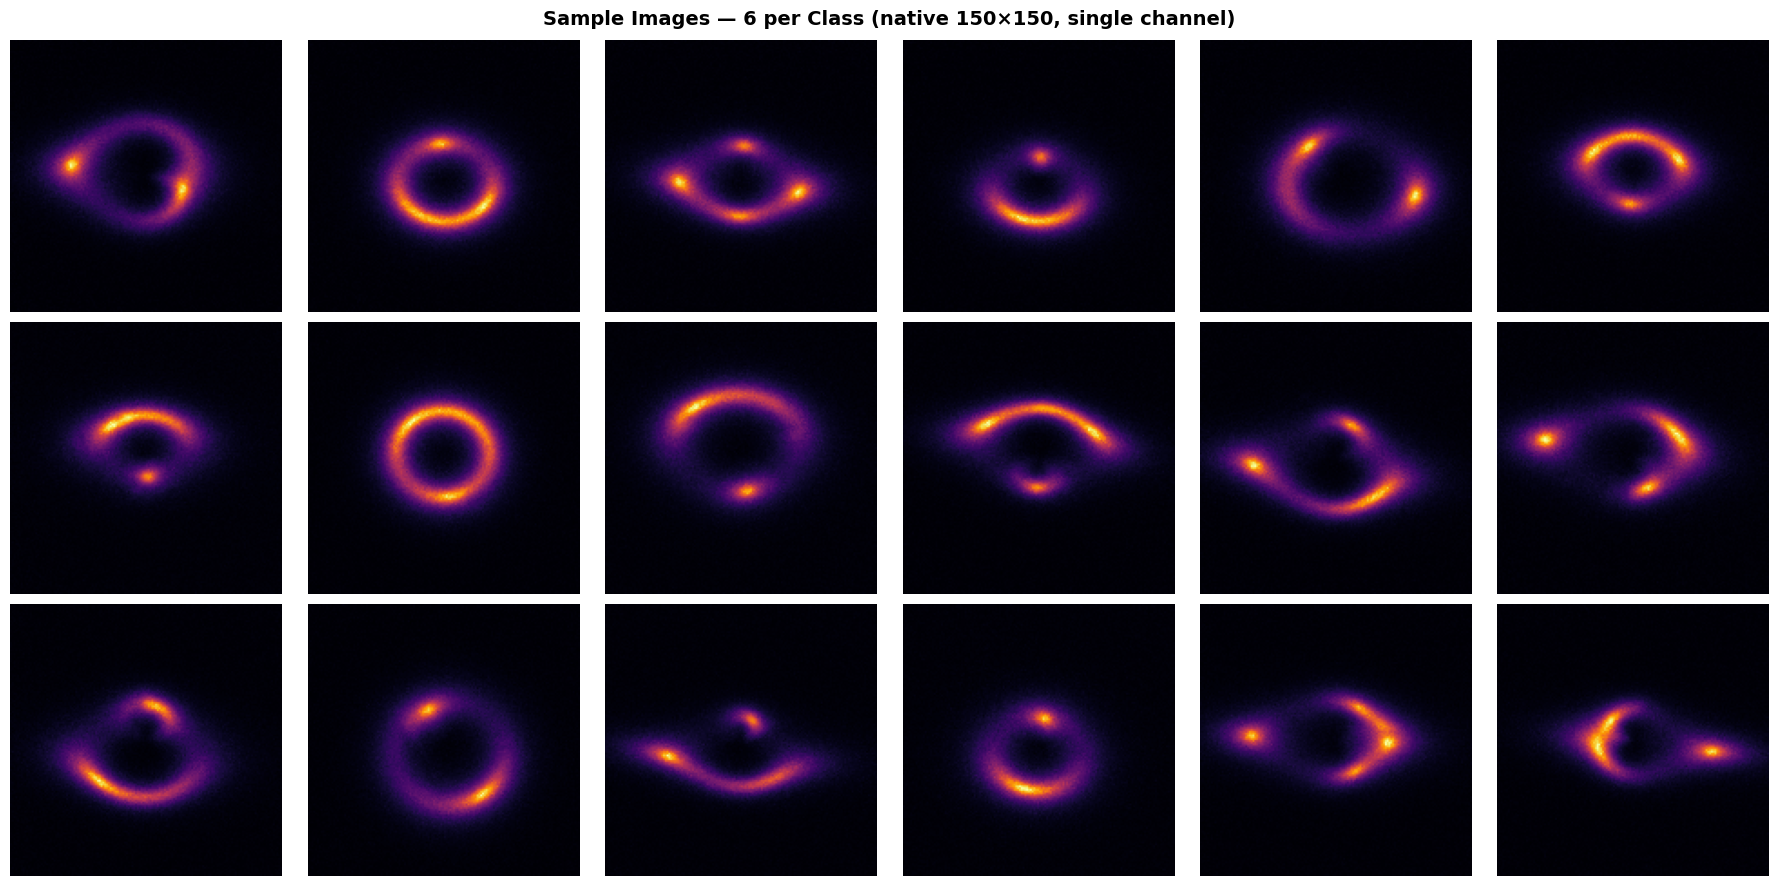

In [6]:
display_names = ['No Substructure', 'Subhalo', 'Vortex']
fig, axes = plt.subplots(3, 6, figsize=(18, 9))
fig.suptitle('Sample Images — 6 per Class (native 150×150, single channel)',
             fontsize=14, fontweight='bold')

for cls_idx, (cls_name, cls_label) in enumerate(CLASS_LABELS.items()):
    idxs   = [i for i, l in enumerate(train_dataset.labels) if l == cls_label]
    chosen = random.sample(idxs, 6)
    for col, img_idx in enumerate(chosen):
        raw = np.load(train_dataset.filepaths[img_idx]).astype(np.float32)
        if raw.ndim == 3: raw = raw[0]
        axes[cls_idx, col].imshow(raw, cmap='inferno', origin='lower')
        axes[cls_idx, col].axis('off')
        if col == 0:
            axes[cls_idx, col].set_ylabel(display_names[cls_idx],
                                           fontsize=11, rotation=90, labelpad=45)

plt.tight_layout()
plt.show()

## 5. Physics Operations

We implement three differentiable physics operations that form the core of the PINN.
All are implemented as pure PyTorch operations — fully differentiable and GPU-compatible.

### 5.1 Gradient: $\boldsymbol{\alpha} = \nabla\psi$
Computes the deflection field from the potential using **central differences** (second-order accurate).  
Because $\boldsymbol{\alpha} = \nabla\psi$ by construction, `curl(α) = 0` is guaranteed — no loss penalty needed.

### 5.2 Laplacian: $\kappa = \frac{1}{2}\nabla^2\psi$
Computes the convergence map — the projected mass density of the lens.  
This is the primary discriminator between the three classes.

### 5.3 Lensing Ray-Tracing: $\boldsymbol{\beta} = \boldsymbol{\theta} - \boldsymbol{\alpha}$
Applies the gravitational lensing equation to map each image-plane pixel  
back to its source-plane position using differentiable bilinear sampling.

In [7]:
def compute_gradient(psi: torch.Tensor) -> tuple[torch.Tensor, torch.Tensor]:
    alpha_x = (psi[:, :, 1:-1, 2:] - psi[:, :, 1:-1, :-2]) / 2.0  
    alpha_y = (psi[:, :, 2:, 1:-1] - psi[:, :, :-2, 1:-1]) / 2.0  
    return alpha_x, alpha_y


def compute_laplacian(psi: torch.Tensor) -> torch.Tensor:
    laplacian = (
        psi[:, :, 2:,  1:-1] +   # f[i+1, j]
        psi[:, :, :-2, 1:-1] +   # f[i-1, j]
        psi[:, :, 1:-1, 2:]  +   # f[i,   j+1]
        psi[:, :, 1:-1, :-2] -   # f[i,   j-1]
        4 * psi[:, :, 1:-1, 1:-1]  # -4 f[i,j]
    )
    kappa = 0.5 * laplacian
    return kappa


def apply_lensing_equation(
    image: torch.Tensor,
    alpha_x: torch.Tensor,
    alpha_y: torch.Tensor
) -> torch.Tensor:
    B, C, H, W = image.shape
    _, _, Hd, Wd = alpha_x.shape

    alpha_x_full = F.interpolate(alpha_x, size=(H, W), mode='bilinear', align_corners=True)
    alpha_y_full = F.interpolate(alpha_y, size=(H, W), mode='bilinear', align_corners=True)

    gy = torch.linspace(-1, 1, H, device=image.device)
    gx = torch.linspace(-1, 1, W, device=image.device)
    grid_y, grid_x = torch.meshgrid(gy, gx, indexing='ij')  # (H, W) each
    grid_x = grid_x.unsqueeze(0).unsqueeze(0).expand(B, 1, H, W)  # (B,1,H,W)
    grid_y = grid_y.unsqueeze(0).unsqueeze(0).expand(B, 1, H, W)

    source_x = torch.clamp(grid_x - alpha_x_full, -1.0, 1.0)  # (B,1,H,W)
    source_y = torch.clamp(grid_y - alpha_y_full, -1.0, 1.0)

    sample_grid = torch.cat([source_x, source_y], dim=1)  # (B, 2, H, W)
    sample_grid = sample_grid.permute(0, 2, 3, 1)          # (B, H, W, 2)

    source_image = F.grid_sample(
        image, sample_grid,
        mode='bilinear', padding_mode='zeros', align_corners=True
    )
    return source_image


def physics_regularisation(
    psi: torch.Tensor,
    kappa: torch.Tensor,
    labels: torch.Tensor
) -> torch.Tensor:
    
    grad_x = (psi[:, :, :, 1:] - psi[:, :, :, :-1])
    grad_y = (psi[:, :, 1:, :] - psi[:, :, :-1, :])
    loss_smooth = (grad_x.pow(2).mean() + grad_y.pow(2).mean()) / 2

    subhalo_mask = (labels == 1).float().view(-1, 1, 1, 1)
    kappa_var    = kappa.var(dim=[-2, -1], keepdim=True)         
    loss_sparsity = (subhalo_mask * (1.0 - kappa_var.clamp(0, 1))).mean()

    return loss_smooth, loss_sparsity


print('Physics operations defined ✓')

Physics operations defined ✓


## 6. PINN Architecture

### Design Rationale

**Backbone: EfficientNet-B3 (pretrained ImageNet)**  
A 3-block from-scratch CNN is insufficient to detect the subtle arc distortions that distinguish  
lensing substructures. EfficientNet-B3 provides deep, pretrained features (edges, curves, textures)  
that transfer directly to lensing arc detection.

**Physics Head: Predicts lensing potential ψ**  
Rather than predicting the deflection field α directly (which could violate curl(α)=0),  
we predict the **scalar potential ψ** from intermediate backbone features.  
The deflection α = ∇ψ and convergence κ = ½∇²ψ are then derived analytically —  
physically consistent by construction.

**Classification Head: Physics-augmented features**  
The final classifier sees:
1. Deep backbone features (appearance)
2. Pooled convergence map κ (projected mass density)
3. Pooled deflection magnitude |α| (distortion strength)

This forces the model to classify based on physically meaningful quantities,  
not arbitrary learned features.

In [13]:
class PotentialHead(nn.Module):
  
    def __init__(self, in_channels: int, hidden: int = 64):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(in_channels, hidden, kernel_size=3, padding=1),
            nn.BatchNorm2d(hidden),
            nn.GELU(),
            nn.Conv2d(hidden, hidden // 2, kernel_size=3, padding=1),
            nn.GELU(),
            nn.Conv2d(hidden // 2, 1, kernel_size=1),  # scalar potential
        )

    def forward(self, features: torch.Tensor) -> torch.Tensor:
        return self.net(features)   # (B, 1, H', W')


class LensingPINN(nn.Module):
    def __init__(self, num_classes: int = 3, dropout: float = 0.4):
        super().__init__()
        efficientnet = models.efficientnet_b3(weights='DEFAULT')
        self.backbone    = efficientnet.features     
        self.avg_pool    = efficientnet.avgpool     
        backbone_out_dim = 1536

        self.intermediate_hook = None
        self._intermediate_features = None
        self._register_intermediate_hook()

        self.potential_head = PotentialHead(in_channels=136, hidden=64)   
        
        self.physics_proj = nn.Linear(2, 64)   
        self.classifier = nn.Sequential(
            nn.Dropout(p=dropout),
            nn.Linear(backbone_out_dim + 64, 512),
            nn.GELU(),
            nn.Dropout(p=dropout * 0.5),
            nn.Linear(512, num_classes)
        )

    def _register_intermediate_hook(self):
        def hook(module, input, output):
            self._intermediate_features = output
        self.intermediate_hook = self.backbone[5].register_forward_hook(hook)

    def forward(self, x: torch.Tensor):
        B = x.shape[0]

        feat_map = self.backbone(x)              # (B, 1536, H', W')
        pooled   = self.avg_pool(feat_map)        # (B, 1536, 1, 1)
        backbone_features = pooled.view(B, -1)    # (B, 1536)

        
        inter_feat = self._intermediate_features  # (B, 136, H_mid, W_mid)
        psi        = self.potential_head(inter_feat)   # (B, 1, H_mid, W_mid)

        alpha_x, alpha_y = compute_gradient(psi)  
        kappa            = compute_laplacian(psi)  
        
       # 4. Pool physics features for classifier
        kappa_pooled    = kappa.abs().mean(dim=[-2, -1]).squeeze(1)      
        alpha_magnitude = (alpha_x.pow(2) + alpha_y.pow(2) + 1e-8).sqrt() 
        alpha_pooled    = alpha_magnitude.mean(dim=[-2, -1]).squeeze(1)   # (B,)
        
        physics_vec     = torch.stack([kappa_pooled, alpha_pooled], dim=1) # (B, 2)
        physics_feat    = self.physics_proj(physics_vec)                   # (B, 64)

        combined = torch.cat([backbone_features, physics_feat], dim=1)  # (B, 1536+64)
        logits   = self.classifier(combined)                              # (B, 3)

        return logits, psi, alpha_x, alpha_y, kappa


model = LensingPINN(num_classes=NUM_CLASSES).to(device)

total_p     = sum(p.numel() for p in model.parameters())
trainable_p = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Total parameters:     {total_p:,}')
print(f'Trainable parameters: {trainable_p:,}')

with torch.no_grad():
    dummy = torch.randn(2, 3, IMAGE_SIZE, IMAGE_SIZE).to(device)
    logits, psi, ax, ay, kappa = model(dummy)
    print(f'Logits shape:    {logits.shape}')
    print(f'ψ shape:         {psi.shape}')
    print(f'α_x, α_y shapes: {ax.shape}, {ay.shape}')
    print(f'κ shape:         {kappa.shape}')

Total parameters:     11,614,700
Trainable parameters: 11,614,700
Logits shape:    torch.Size([2, 3])
ψ shape:         torch.Size([2, 1, 10, 10])
α_x, α_y shapes: torch.Size([2, 1, 8, 8]), torch.Size([2, 1, 8, 8])
κ shape:         torch.Size([2, 1, 8, 8])


## 7. Loss Function — Adaptive Physics-Informed Training

### The Collapsing Physics Loss Problem

A critical failure mode in PINN training is the **physics loss collapsing to near-zero**  
while the classification loss dominates. This makes the physics constraint irrelevant.

We solve this with **adaptive loss weighting** (GradNorm-inspired):  
at each step, the physics loss weight is adjusted so that both losses contribute  
roughly equal gradient magnitudes.

$$\lambda_{\text{phys}} = \frac{\mathcal{L}_{\text{class}}}{\mathcal{L}_{\text{phys}} + \epsilon}$$

This ensures the physics constraint always has real influence on training.

In [14]:
criterion_class = nn.CrossEntropyLoss(label_smoothing=0.1)


def compute_total_loss(
    logits, psi, kappa,
    labels,
    lambda_smooth=LAMBDA_SMOOTH,
    lambda_kappa=LAMBDA_KAPPA
):
   
    loss_class = criterion_class(logits, labels)

    loss_smooth, loss_sparsity = physics_regularisation(psi, kappa, labels)

    with torch.no_grad():
        phys_combined = lambda_smooth * loss_smooth + lambda_kappa * loss_sparsity
        adaptive_lambda = loss_class.detach() / (phys_combined.detach() + 1e-8)
        adaptive_lambda = adaptive_lambda.clamp(0.1, 10.0)

    total_loss = (
        loss_class
        + adaptive_lambda * lambda_smooth  * loss_smooth
        + adaptive_lambda * lambda_kappa   * loss_sparsity
    )

    return total_loss, loss_class, loss_smooth, loss_sparsity, adaptive_lambda.item()


print('Loss function defined ✓')

Loss function defined ✓


## 8. Optimiser & Scheduler

| Component | Choice | Rationale |
|---|---|---|
| Optimiser | AdamW | Decoupled weight decay — more stable for PINN training |
| LR Schedule | CosineAnnealingWarmRestarts | Periodic restarts escape local minima common in multi-objective loss |
| Mixed Precision | GradScaler + autocast | ~2× speed, crucial for 150×150 inputs |
| Grad Clipping | max_norm=1.0 | Prevents exploding gradients from physics loss spikes |
| Label Smoothing | 0.1 | Prevents overconfident predictions |

In [15]:
optimizer = optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

scheduler = optim.lr_scheduler.CosineAnnealingWarmRestarts(
    optimizer, T_0=10, T_mult=2, eta_min=1e-6
)

scaler = GradScaler()

print('Optimiser & scheduler ready ✓')

Optimiser & scheduler ready ✓


## 9. Training Loop with Validation & Early Stopping

We track **four quantities** per epoch to ensure complete observability:
1. Training loss (classification + physics)
2. Validation loss
3. Validation macro AUC (primary metric)
4. Adaptive physics lambda (to verify the physics constraint stays active)

The best model is saved by **validation macro AUC** and early stopping is applied with patience=7.

In [16]:
@torch.no_grad()
def evaluate(model, loader, device):
    model.eval()
    total_loss = 0.0
    all_probs, all_targets = [], []

    for images, labels in loader:
        images, labels = images.to(device), labels.to(device)
        with autocast():
            logits, psi, _, _, kappa = model(images)
            loss, loss_c, ls, lk, _ = compute_total_loss(logits, psi, kappa, labels)
        total_loss += loss.item()
        probs = F.softmax(logits, dim=1)
        all_probs.append(probs.cpu().numpy())
        all_targets.append(labels.cpu().numpy())

    all_probs   = np.vstack(all_probs)
    all_targets = np.concatenate(all_targets)
    y_bin       = label_binarize(all_targets, classes=list(range(NUM_CLASSES)))
    macro_auc   = roc_auc_score(y_bin, all_probs, average='macro')
    avg_loss    = total_loss / len(loader)

    return avg_loss, macro_auc, all_probs, all_targets


history = {
    'train_loss': [], 'train_class': [], 'train_phys': [],
    'val_loss': [], 'val_auc': [],
    'lambda_adaptive': [], 'lr': []
}

best_val_auc = 0.0
no_improve   = 0

print(f'Training for up to {NUM_EPOCHS} epochs  (early stop patience={EARLY_STOP_P})\n')
print(f'{"Ep":>3} {"T-Loss":>8} {"T-Class":>8} {"T-Phys":>8} {"V-Loss":>8} {"V-AUC":>8} {"λ":>7} {"LR":>10}')
print('─' * 72)

for epoch in range(1, NUM_EPOCHS + 1):
    model.train()
    metrics = {'total': 0.0, 'class': 0.0, 'phys': 0.0, 'lambda': 0.0}

    for images, labels in tqdm(train_loader, desc=f'Ep {epoch:02d}', leave=False):
        images, labels = images.to(device), labels.to(device)
        optimizer.zero_grad(set_to_none=True)

        with autocast():
            logits, psi, alpha_x, alpha_y, kappa = model(images)
            total_loss, loss_c, loss_s, loss_k, lam = compute_total_loss(
                logits, psi, kappa, labels
            )

        scaler.scale(total_loss).backward()
        scaler.unscale_(optimizer)
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        scaler.step(optimizer)
        scaler.update()

        metrics['total']  += total_loss.item()
        metrics['class']  += loss_c.item()
        metrics['phys']   += (loss_s + loss_k).item()
        metrics['lambda'] += lam

    scheduler.step(epoch - 1)
    n = len(train_loader)

    val_loss, val_auc, _, _ = evaluate(model, val_loader, device)
    current_lr = optimizer.param_groups[0]['lr']

    history['train_loss'].append(metrics['total'] / n)
    history['train_class'].append(metrics['class'] / n)
    history['train_phys'].append(metrics['phys'] / n)
    history['val_loss'].append(val_loss)
    history['val_auc'].append(val_auc)
    history['lambda_adaptive'].append(metrics['lambda'] / n)
    history['lr'].append(current_lr)

    print(f'{epoch:>3} {metrics["total"]/n:>8.4f} {metrics["class"]/n:>8.4f} '
          f'{metrics["phys"]/n:>8.5f} {val_loss:>8.4f} {val_auc:>8.4f} '
          f'{metrics["lambda"]/n:>7.2f} {current_lr:>10.2e}')

    if val_auc > best_val_auc:
        best_val_auc = val_auc
        no_improve   = 0
        torch.save({
            'epoch':            epoch,
            'model_state_dict': model.state_dict(),
            'val_auc':          val_auc,
            'val_loss':         val_loss,
            'train_mean':       TRAIN_MEAN,
            'train_std':        TRAIN_STD,
        }, CKPT_PATH)
        print(f'   ✅ Best model saved  (Macro AUC={best_val_auc:.4f})')
    else:
        no_improve += 1
        if no_improve >= EARLY_STOP_P:
            print(f'\nEarly stopping at epoch {epoch}')
            break

print(f'\n🏁 Training complete. Best Val Macro AUC: {best_val_auc:.4f}')

Training for up to 40 epochs  (early stop patience=7)

 Ep   T-Loss  T-Class   T-Phys   V-Loss    V-AUC       λ         LR
────────────────────────────────────────────────────────────────────────


Ep 01:   0%|          | 0/468 [00:00<?, ?it/s]

  1   1.0719   0.9182  0.28859   0.7895   0.9191   10.00   1.00e-03
   ✅ Best model saved  (Macro AUC=0.9191)


Ep 02:   0%|          | 0/468 [00:00<?, ?it/s]

  2   0.7145   0.6067  0.15813   0.6486   0.9639   10.00   9.76e-04
   ✅ Best model saved  (Macro AUC=0.9639)


...

 16   0.4807   0.4062  0.09034   0.4922   0.9879   10.00   8.54e-04


Ep 17:   0%|          | 0/468 [00:00<?, ?it/s]

 17   0.4718   0.3977  0.08876   0.4701   0.9911   10.00   7.94e-04


Ep 18:   0%|          | 0/468 [00:00<?, ?it/s]

 18   0.4633   0.3904  0.08697   0.4754   0.9889   10.00   7.27e-04

Early stopping at epoch 18

🏁 Training complete. Best Val Macro AUC: 0.9931


## 10. Training Diagnostics

We plot four curves to verify PINN training health:
1. **Loss curves** — train vs val loss divergence signals overfitting
2. **Val macro AUC** — primary metric trajectory
3. **Physics loss** — must stay non-trivial throughout (not collapse to ~0)
4. **Adaptive lambda** — shows how physics weight evolves to balance training

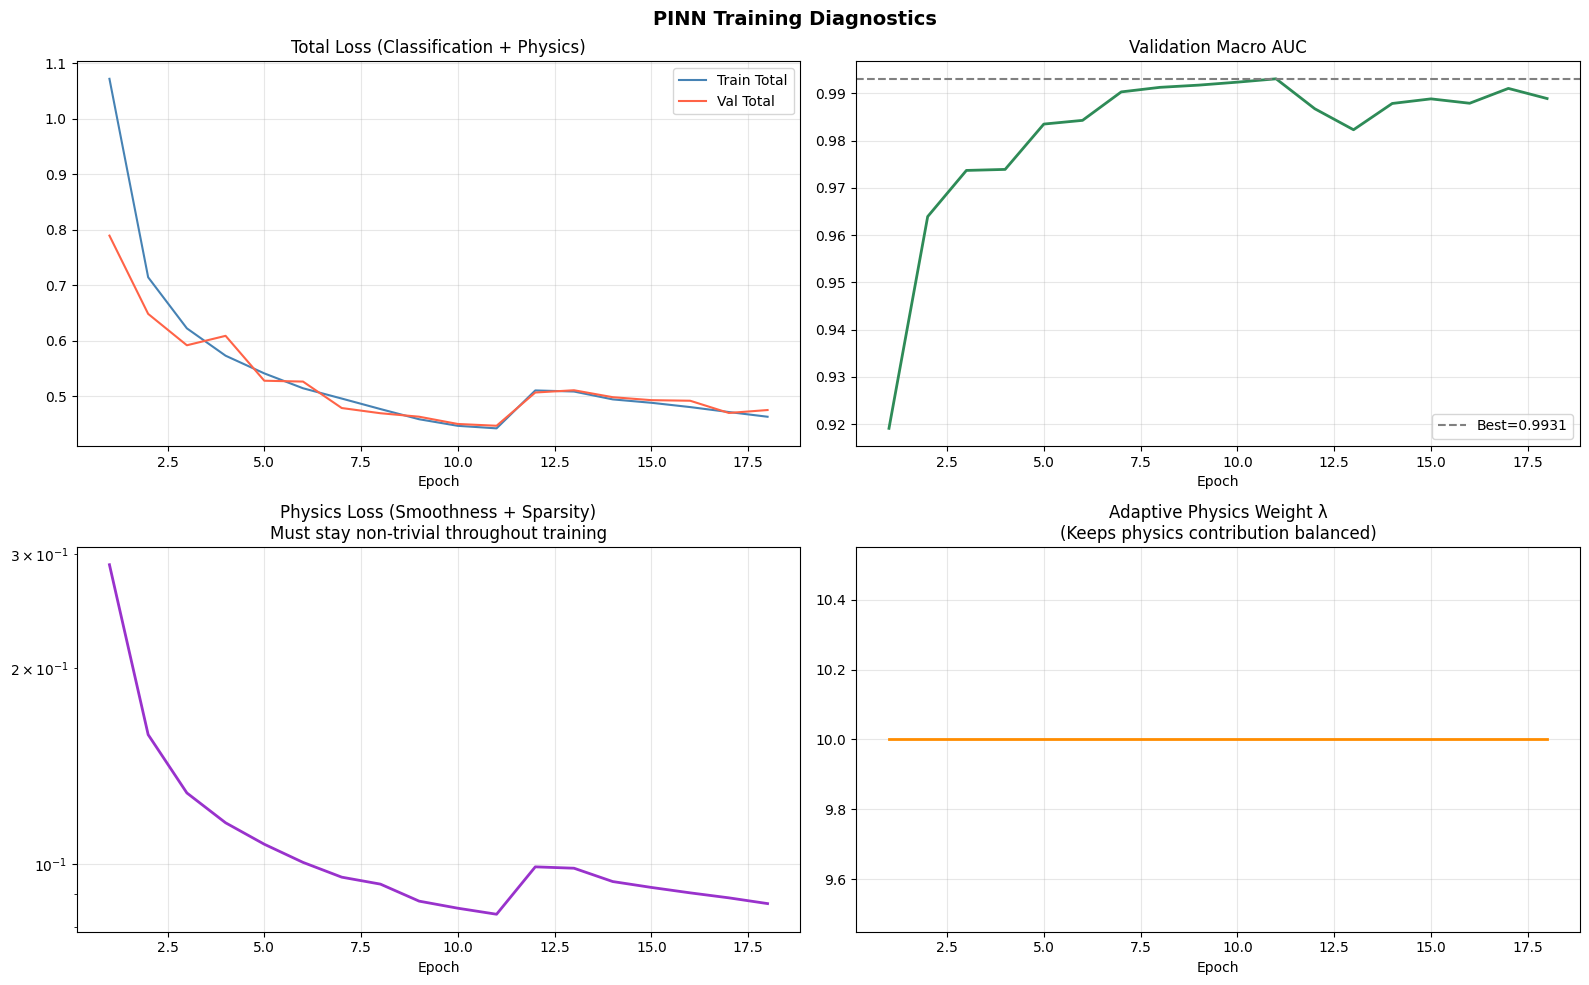

In [17]:
ep = range(1, len(history['train_loss']) + 1)

fig, axes = plt.subplots(2, 2, figsize=(16, 10))
fig.suptitle('PINN Training Diagnostics', fontsize=14, fontweight='bold')

# Loss
axes[0,0].plot(ep, history['train_loss'], label='Train Total', color='steelblue')
axes[0,0].plot(ep, history['val_loss'],   label='Val Total',   color='tomato')
axes[0,0].set_title('Total Loss (Classification + Physics)')
axes[0,0].legend(); axes[0,0].grid(alpha=0.3)

# AUC
axes[0,1].plot(ep, history['val_auc'], color='seagreen', lw=2)
axes[0,1].axhline(best_val_auc, linestyle='--', color='gray',
                  label=f'Best={best_val_auc:.4f}')
axes[0,1].set_title('Validation Macro AUC')
axes[0,1].legend(); axes[0,1].grid(alpha=0.3)

axes[1,0].plot(ep, history['train_phys'], color='darkorchid', lw=2)
axes[1,0].set_title('Physics Loss (Smoothness + Sparsity)\nMust stay non-trivial throughout training')
axes[1,0].set_yscale('log'); axes[1,0].grid(alpha=0.3)

# Adaptive lambda
axes[1,1].plot(ep, history['lambda_adaptive'], color='darkorange', lw=2)
axes[1,1].set_title('Adaptive Physics Weight λ\n(Keeps physics contribution balanced)')
axes[1,1].grid(alpha=0.3)

for ax in axes.flatten(): ax.set_xlabel('Epoch')
plt.tight_layout()
plt.show()

## 11. Final Evaluation with TTA

We load the best checkpoint and run **Test-Time Augmentation** (5 passes)  
on the validation set for final metric reporting.

In [19]:
ckpt = torch.load(CKPT_PATH, map_location=device, weights_only=False)
model.load_state_dict(ckpt['model_state_dict'])
print(f"Best model: epoch {ckpt['epoch']}  (Val AUC={ckpt['val_auc']:.4f})")


@torch.no_grad()
def predict_tta(model, data_root, device, n_steps=TTA_STEPS):
    """TTA: average softmax probabilities over n_steps augmented passes."""
    model.eval()
    accumulated = None
    true_labels = None

    for step in range(n_steps):
        tfm = val_transform if step == 0 else tta_transform
        ds  = LensingDataset(data_root, transform=tfm)
        dl  = DataLoader(ds, batch_size=BATCH_SIZE, shuffle=False,
                         num_workers=NUM_WORKERS, pin_memory=True)
        step_probs, step_labels = [], []
        for images, labels in dl:
            with autocast():
                logits, *_ = model(images.to(device))
            step_probs.append(F.softmax(logits, dim=1).cpu().numpy())
            if step == 0:
                step_labels.append(labels.numpy())
        step_probs = np.vstack(step_probs)
        accumulated = step_probs if accumulated is None else accumulated + step_probs
        if step == 0:
            true_labels = np.concatenate(step_labels)

    return accumulated / n_steps, true_labels


print(f'Running TTA ({TTA_STEPS} passes) on validation set...')
tta_probs, true_labels = predict_tta(model, VAL_DIR, device)

# Baseline (no TTA)
_, base_auc, base_probs, _ = evaluate(model, val_loader, device)

y_bin    = label_binarize(true_labels, classes=list(range(NUM_CLASSES)))
tta_auc  = roc_auc_score(y_bin, tta_probs, average='macro')

print(f'\nBaseline Macro AUC (no TTA): {base_auc:.4f}')
print(f'TTA Macro AUC ({TTA_STEPS} passes):    {tta_auc:.4f}  (+{tta_auc - base_auc:.4f})')

Best model: epoch 11  (Val AUC=0.9931)
Running TTA (5 passes) on validation set...

Baseline Macro AUC (no TTA): 0.9931
TTA Macro AUC (5 passes):    0.9940  (+0.0009)


## 12. Full Metrics & Visualisation

We report the complete evaluation suite:
- Per-class and macro ROC-AUC
- Confusion matrix
- Classification report

FINAL EVALUATION — PINN with TTA
  No Substructure         AUC = 0.9941
  Subhalo                 AUC = 0.9906
  Vortex                  AUC = 0.9974
  Macro-averaged          AUC = 0.9940
─────────────────────────────────────────────────────────────────
                 precision    recall  f1-score   support

No Substructure     0.9364    0.9948    0.9647      2500
        Subhalo     0.9755    0.9252    0.9497      2500
         Vortex     0.9778    0.9672    0.9725      2500

       accuracy                         0.9624      7500
      macro avg     0.9632    0.9624    0.9623      7500
   weighted avg     0.9632    0.9624    0.9623      7500



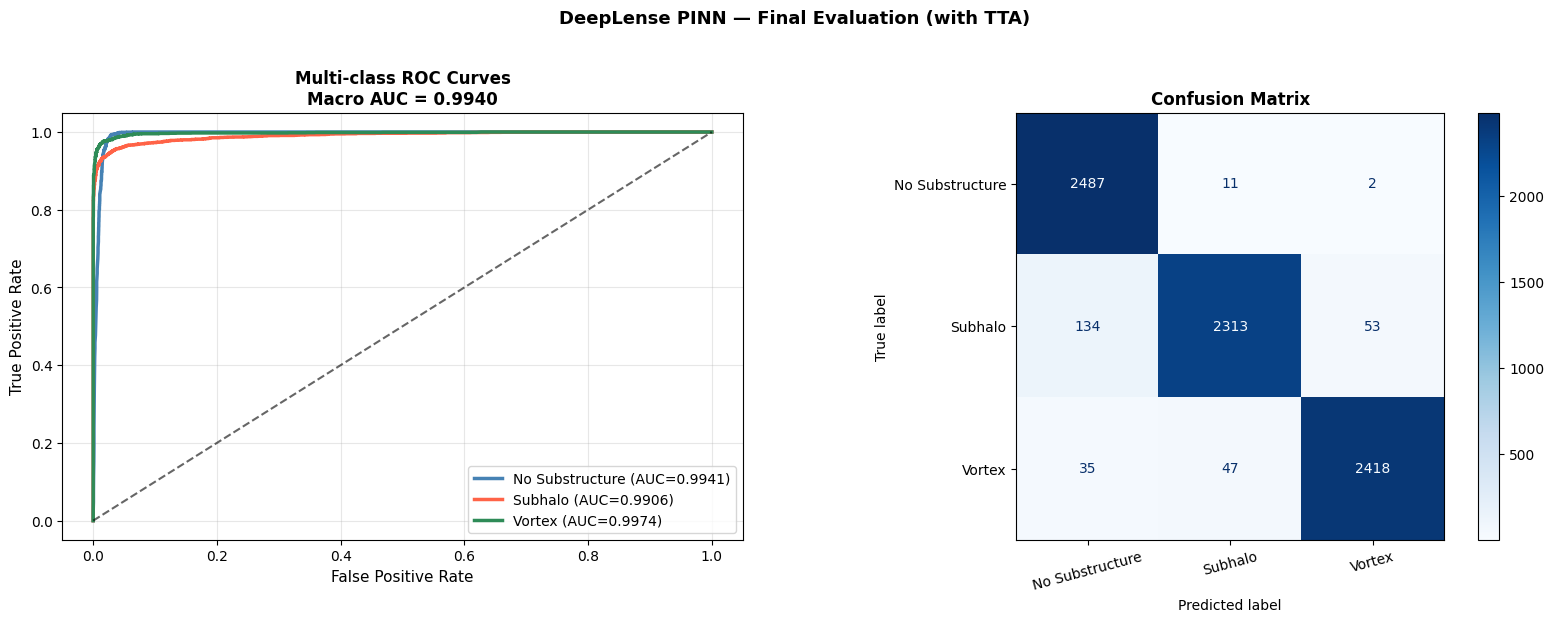

In [20]:
final_probs = tta_probs
final_preds = np.argmax(final_probs, axis=1)
display_names = ['No Substructure', 'Subhalo', 'Vortex']

# ── Print metrics ─────────────────────────────────────────────────────────────
print('=' * 65)
print('FINAL EVALUATION — PINN with TTA')
print('=' * 65)
for i, name in enumerate(display_names):
    cls_auc = roc_auc_score(y_bin[:, i], final_probs[:, i])
    print(f'  {name:<22}  AUC = {cls_auc:.4f}')
print(f'  {"Macro-averaged":<22}  AUC = {tta_auc:.4f}')
print('─' * 65)
print(classification_report(true_labels, final_preds,
                             target_names=display_names, digits=4))

# ── Plots ─────────────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(16, 6))
gs  = gridspec.GridSpec(1, 2, figure=fig)

# ROC Curves
ax_roc = fig.add_subplot(gs[0, 0])
colors = ['steelblue', 'tomato', 'seagreen']
for i, (name, color) in enumerate(zip(display_names, colors)):
    fpr, tpr, _ = roc_curve(y_bin[:, i], final_probs[:, i])
    cls_auc     = auc(fpr, tpr)
    ax_roc.plot(fpr, tpr, color=color, lw=2.5,
                label=f'{name} (AUC={cls_auc:.4f})')
ax_roc.plot([0, 1], [0, 1], 'k--', lw=1.5, alpha=0.6)
ax_roc.set_xlabel('False Positive Rate', fontsize=11)
ax_roc.set_ylabel('True Positive Rate', fontsize=11)
ax_roc.set_title(f'Multi-class ROC Curves\nMacro AUC = {tta_auc:.4f}',
                 fontsize=12, fontweight='bold')
ax_roc.legend(loc='lower right'); ax_roc.grid(alpha=0.3)

# Confusion Matrix
ax_cm = fig.add_subplot(gs[0, 1])
cm    = confusion_matrix(true_labels, final_preds)
disp  = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=display_names)
disp.plot(ax=ax_cm, colorbar=True, cmap='Blues')
ax_cm.set_title('Confusion Matrix', fontsize=12, fontweight='bold')
ax_cm.tick_params(axis='x', rotation=15)

plt.suptitle('DeepLense PINN — Final Evaluation (with TTA)',
             fontsize=13, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## 13. Physics Visualisation — Lensing Fields

A key advantage of the PINN is **interpretability**: we can visualise the predicted  
lensing potential ψ, deflection field α, and convergence κ for each class.

These visualisations demonstrate that the network has learned physically meaningful  
intermediate representations — not just arbitrary features:
- **No substructure:** ψ smooth, κ broad and symmetric
- **Subhalo:** κ shows localised peaks corresponding to dark matter clumps
- **Vortex:** α shows azimuthal rotation pattern

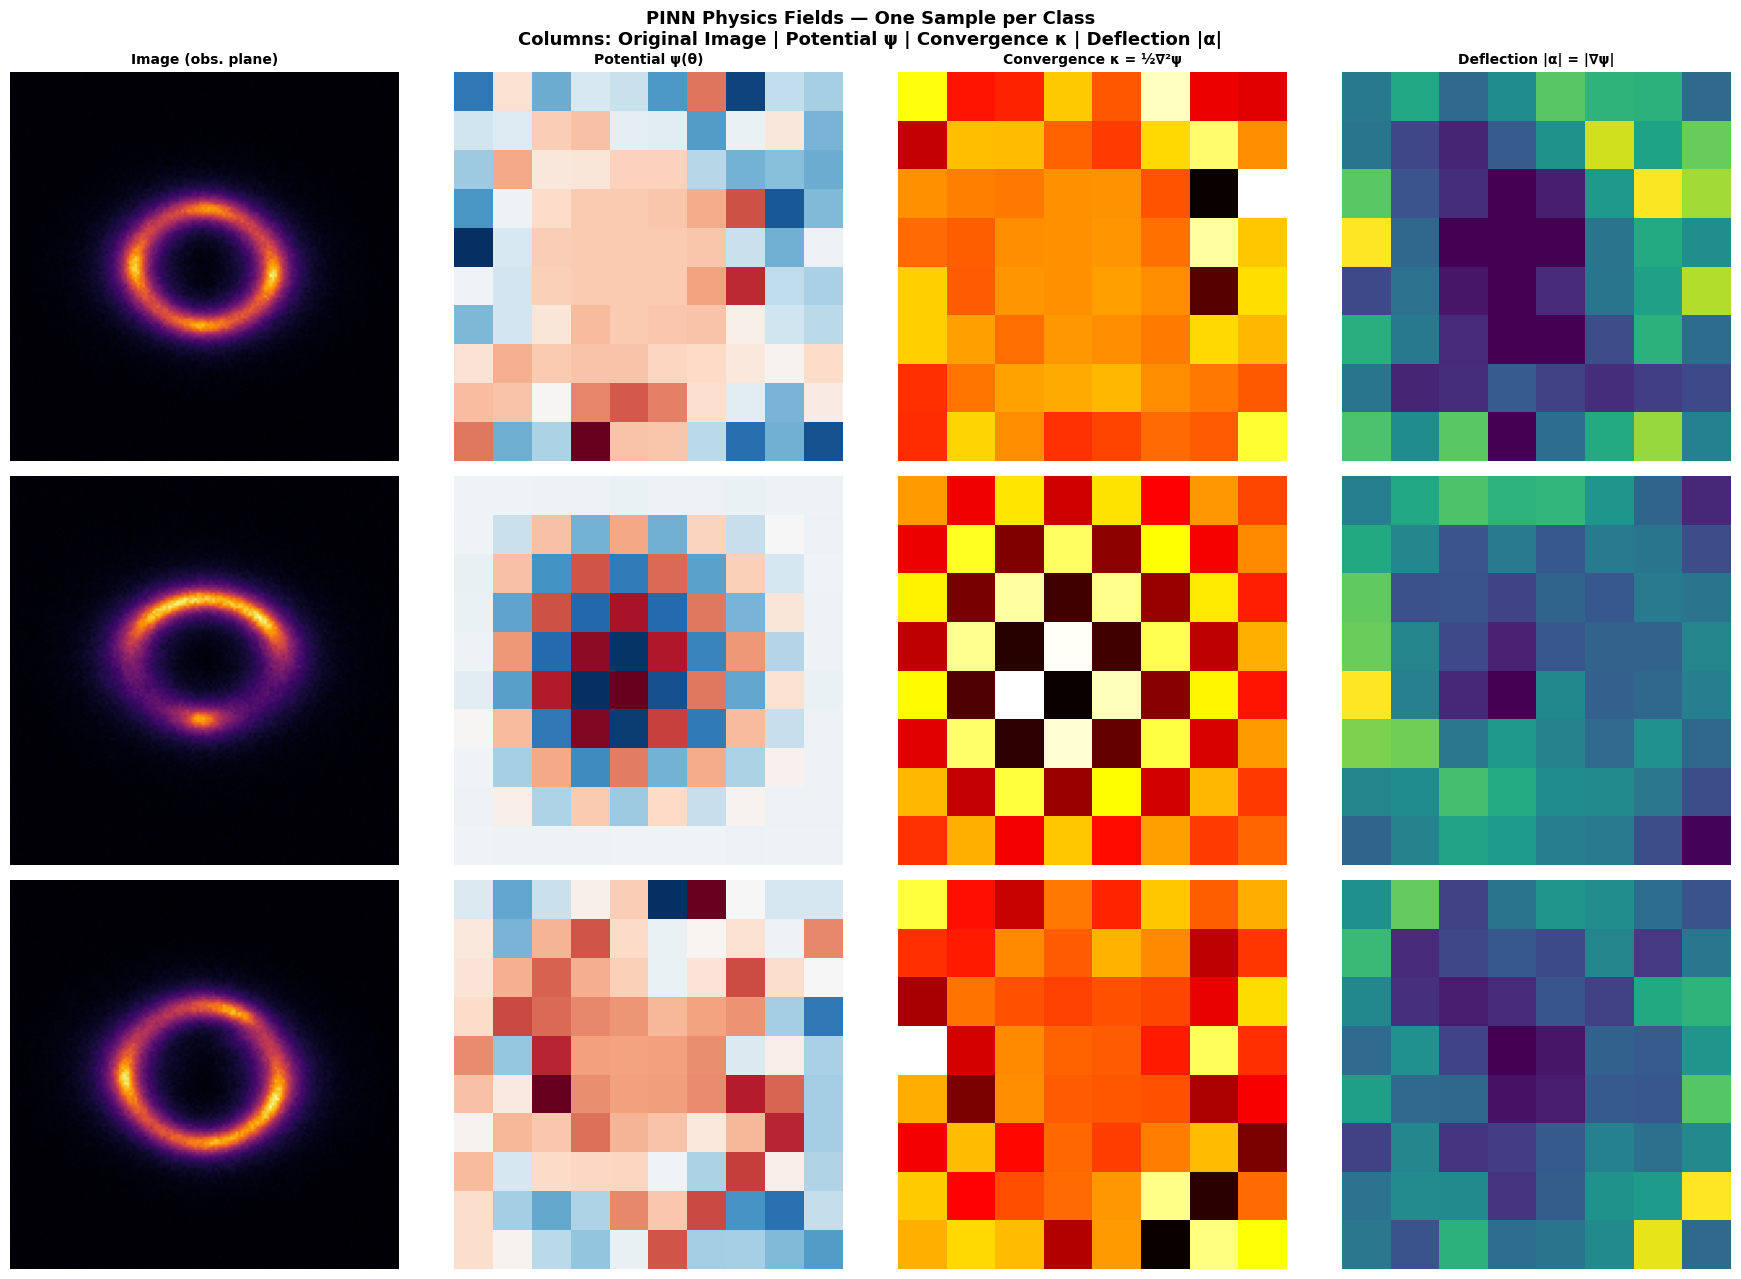


Physics visualisation complete.
Compare κ maps across classes — localised peaks = subhalo, smooth = no substructure


In [21]:
model.eval()
val_ds_plain = LensingDataset(VAL_DIR, transform=val_transform)

fig, axes = plt.subplots(3, 4, figsize=(18, 13))
fig.suptitle('PINN Physics Fields — One Sample per Class\n'
             'Columns: Original Image | Potential ψ | Convergence κ | Deflection |α|',
             fontsize=13, fontweight='bold')

col_titles = ['Image (obs. plane)', 'Potential ψ(θ)', 'Convergence κ = ½∇²ψ', 'Deflection |α| = |∇ψ|']
for col, title in enumerate(col_titles):
    axes[0, col].set_title(title, fontsize=10, fontweight='bold')

for cls_idx, cls_name in enumerate(CLASS_NAMES):
    # Find a sample from this class
    sample_idxs = [i for i, l in enumerate(val_ds_plain.labels) if l == cls_idx]
    idx = sample_idxs[0]
    img_tensor, label = val_ds_plain[idx]
    img_batch = img_tensor.unsqueeze(0).to(device)

    with torch.no_grad():
        with autocast():
            _, psi, alpha_x, alpha_y, kappa = model(img_batch)

    # Move to CPU
    img_np    = img_tensor[0].cpu().numpy()           # (H, W)
    psi_np    = psi[0, 0].cpu().float().numpy()
    kappa_np  = kappa[0, 0].cpu().float().numpy()
    alpha_mag = (alpha_x[0, 0].pow(2) + alpha_y[0, 0].pow(2)).sqrt().cpu().float().numpy()

    # Row label
    axes[cls_idx, 0].set_ylabel(display_names[cls_idx], fontsize=11,
                                 rotation=90, labelpad=40)

    # Plot
    axes[cls_idx, 0].imshow(img_np,    cmap='inferno', origin='lower')
    axes[cls_idx, 1].imshow(psi_np,    cmap='RdBu_r',  origin='lower')
    axes[cls_idx, 2].imshow(kappa_np,  cmap='hot',     origin='lower')
    axes[cls_idx, 3].imshow(alpha_mag, cmap='viridis',  origin='lower')

    for ax in axes[cls_idx]:
        ax.axis('off')

plt.tight_layout()
plt.show()
print('\nPhysics visualisation complete.')
print('Compare κ maps across classes — localised peaks = subhalo, smooth = no substructure')

## 14. Summary


| Component | Physics | Implementation |
|---|---|---|
| Lensing equation β = θ - α | Relates observed to true position | Applied as differentiable `grid_sample` layer |
| Deflection field α = ∇ψ | α must be curl-free (conservative field) | Derived analytically from ψ — guaranteed by construction |
| Convergence κ = ½∇²ψ | Projected mass density of lens | Computed via 5-point Laplacian stencil |
| Smoothness regularisation | ψ smooth for no-substructure | Tikhonov penalty on ‖∇ψ‖² |
| Sparsity regularisation | Localised κ peaks for subhalo | Variance penalty on κ for class 1 |
| Adaptive λ | Physics loss stays non-trivial | Auto-scaled to match classification loss magnitude |


